# Hyperparameter Tuning - Seoul Bike Sharing Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Linear Regression, Random Forest, XGBoost, SVR

Dataset: Seoul Bike Sharing Demand - 8,761 samples, 12+ features

Experiment tracking with MLflow

**Regression Problem** - Predicting hourly bike rental count

In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

In [3]:
# Load dataset
df = pd.read_csv('data/raw/SeoulBikeData.csv', encoding='unicode_escape')

print(f'Dataset shape: {df.shape}')
print('\nFirst few rows:')
print(df.head())
print('\nColumn info:')
print(df.dtypes.unique()[:5])

Dataset shape: (8760, 14)

First few rows:
         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   
2  01/12/2017                173     2             -6.0           39   
3  01/12/2017                107     3             -6.2           40   
4  01/12/2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0          

In [4]:
# Define target and features
y = df['Rented Bike Count']
feature_cols = [x for x in df.columns if x not in ['Date', 'Rented Bike Count']]

# One-hot encode categorical variables
X = pd.get_dummies(df[feature_cols], drop_first=True)

print(f'\nTarget distribution:')
print(y.describe())
print(f'\nFeature shape: {X.shape}')
print(f'Features: {list(X.columns)[:5]}... (+ {X.shape[1]-5} more)')


Target distribution:
count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: Rented Bike Count, dtype: float64

Feature shape: (8760, 14)
Features: ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)']... (+ 9 more)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'Target range - Train: [{y_train.min()}, {y_train.max()}]')
print(f'Target range - Test: [{y_test.min()}, {y_test.max()}]')

X_train shape: (7008, 14), X_test shape: (1752, 14)
Target range - Train: [0, 3418]
Target range - Test: [0, 3556]


## 2. Baseline Models (MLflow Tracked)

In [6]:
mlflow.set_experiment('bike_sharing_hyperparameter_tuning')

baseline_results = {}
models = {
    'Linear': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'SVR': SVR()
}

for name, model in models.items():
    with mlflow.start_run(run_name=f'baseline_{name.lower()}'):
        # Use scaled data for Linear and SVR
        if name in ['Linear', 'SVR']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        mlflow.log_param('model', name)
        mlflow.log_param('random_state', 42)
        mlflow.log_metric('mae', mae)
        mlflow.log_metric('rmse', rmse)
        mlflow.log_metric('r2', r2)
        
        baseline_results[name] = {
            'mae': mae, 'rmse': rmse, 'r2': r2, 'model': model
        }
        print(f'{name:15s} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}')

Linear          - MAE: 330.39, RMSE: 440.78, R2: 0.5337
RandomForest    - MAE: 144.72, RMSE: 240.28, R2: 0.8614
XGBoost         - MAE: 149.80, RMSE: 240.90, R2: 0.8607
SVR             - MAE: 343.56, RMSE: 518.20, R2: 0.3555


## 3. Cross-Validation Analysis

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

model_configs = {
    'Linear': (LinearRegression(), X_train_scaled, y_train),
    'RandomForest': (RandomForestRegressor(random_state=42), X_train, y_train),
    'XGBoost': (XGBRegressor(random_state=42, verbosity=0), X_train, y_train),
    'SVR': (SVR(), X_train_scaled, y_train)
}

for name, (model, X_data, y_data) in model_configs.items():
    with mlflow.start_run(run_name=f'cv_{name.lower()}'):
        scores_mae = cross_val_score(model, X_data, y_data, cv=cv, scoring='neg_mean_absolute_error')
        scores_rmse = np.sqrt(-cross_val_score(model, X_data, y_data, cv=cv, scoring='neg_mean_squared_error'))
        scores_r2 = cross_val_score(model, X_data, y_data, cv=cv, scoring='r2')
        
        cv_results[name] = {'mae': -scores_mae, 'rmse': scores_rmse, 'r2': scores_r2}
        
        mlflow.log_param('model', name)
        mlflow.log_param('cv', 5)
        mlflow.log_metric('cv_mae_mean', -scores_mae.mean())
        mlflow.log_metric('cv_mae_std', scores_mae.std())
        mlflow.log_metric('cv_rmse_mean', scores_rmse.mean())
        mlflow.log_metric('cv_r2_mean', scores_r2.mean())
        
        print(f'{name:15s} - MAE: {-scores_mae.mean():.2f} (+/- {scores_mae.std():.2f}')
        print(f'{"":15s} - RMSE: {scores_rmse.mean():.2f} (+/- {scores_rmse.std():.2f}')
        print(f'{"":15s} - R2: {scores_r2.mean():.4f} (+/- {scores_r2.std():.4f}')

Linear          - MAE: 322.04 (+/- 3.72
                - RMSE: 431.46 (+/- 5.65
                - R2: 0.5519 (+/- 0.0083
RandomForest    - MAE: 142.38 (+/- 2.50
                - RMSE: 230.19 (+/- 3.62
                - R2: 0.8722 (+/- 0.0082
XGBoost         - MAE: 147.24 (+/- 3.75
                - RMSE: 230.26 (+/- 6.85
                - R2: 0.8721 (+/- 0.0103
SVR             - MAE: 359.67 (+/- 5.30
                - RMSE: 530.79 (+/- 9.81
                - R2: 0.3220 (+/- 0.0049


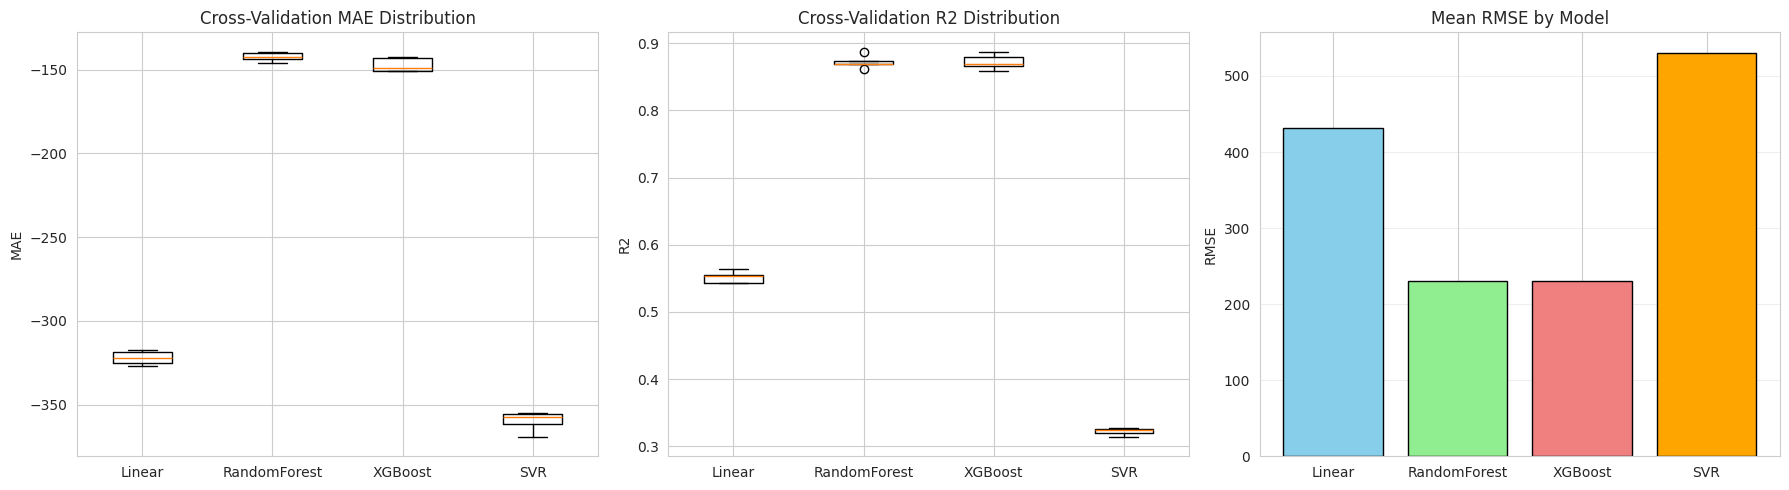

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_list = list(cv_results.keys())

# MAE boxplot
axes[0].boxplot([-cv_results[m]['mae'] for m in models_list], labels=models_list)
axes[0].set_title('Cross-Validation MAE Distribution')
axes[0].set_ylabel('MAE')

# R2 boxplot
axes[1].boxplot([cv_results[m]['r2'] for m in models_list], labels=models_list)
axes[1].set_title('Cross-Validation R2 Distribution')
axes[1].set_ylabel('R2')

# RMSE comparison bar
rmse_means = [cv_results[m]['rmse'].mean() for m in models_list]
axes[2].bar(models_list, rmse_means, color=['skyblue', 'lightgreen', 'lightcoral', 'orange'], edgecolor='black')
axes[2].set_title('Mean RMSE by Model')
axes[2].set_ylabel('RMSE')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

In [9]:
# Linear Regression Grid Search
lin_param_grid = {
    'fit_intercept': [True, False],
}

with mlflow.start_run(run_name='gridsearch_linear'):
    lin_grid = GridSearchCV(
        LinearRegression(), lin_param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    lin_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(lin_grid.best_params_)
    mlflow.log_metric('best_cv_mae', -lin_grid.best_score_)
    lin_best = lin_grid.best_estimator_
    y_pred = lin_best.predict(X_test_scaled)
    test_mae = mean_absolute_error(y_test, y_pred)
    mlflow.log_metric('test_mae', test_mae)
    print(f'Best Linear Params: {lin_grid.best_params_}')
    print(f'Best CV MAE: {-lin_grid.best_score_:.2f}, Test MAE: {test_mae:.2f}')

# RandomForest Grid Search
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

with mlflow.start_run(run_name='gridsearch_randomforest'):
    rf_grid = GridSearchCV(
        RandomForestRegressor(random_state=42), rf_param_grid, cv=5,
        scoring='neg_mean_absolute_error', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    mlflow.log_params(rf_grid.best_params_)
    mlflow.log_metric('best_cv_mae', -rf_grid.best_score_)
    rf_best = rf_grid.best_estimator_
    y_pred = rf_best.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_pred)
    mlflow.log_metric('test_mae', test_mae)
    print(f'Best RF Params: {rf_grid.best_params_}')
    print(f'Best CV MAE: {-rf_grid.best_score_:.2f}, Test MAE: {test_mae:.2f}')

# XGBoost Grid Search
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name='gridsearch_xgboost'):
    xgb_grid = GridSearchCV(
        XGBRegressor(random_state=42, verbosity=0), xgb_param_grid, cv=5,
        scoring='neg_mean_absolute_error', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('best_cv_mae', -xgb_grid.best_score_)
    xgb_best = xgb_grid.best_estimator_
    y_pred = xgb_best.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_pred)
    mlflow.log_metric('test_mae', test_mae)
    print(f'Best XGBoost Params: {xgb_grid.best_params_}')
    print(f'Best CV MAE: {-xgb_grid.best_score_:.2f}, Test MAE: {test_mae:.2f}')

# SVR Grid Search
svr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

with mlflow.start_run(run_name='gridsearch_svr'):
    svr_grid = GridSearchCV(
        SVR(), svr_param_grid, cv=5,
        scoring='neg_mean_absolute_error', n_jobs=-1)
    svr_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(svr_grid.best_params_)
    mlflow.log_metric('best_cv_mae', -svr_grid.best_score_)
    svr_best = svr_grid.best_estimator_
    y_pred = svr_best.predict(X_test_scaled)
    test_mae = mean_absolute_error(y_test, y_pred)
    mlflow.log_metric('test_mae', test_mae)
    print(f'Best SVR Params: {svr_grid.best_params_}')
    print(f'Best CV MAE: {-svr_grid.best_score_:.2f}, Test MAE: {test_mae:.2f}')

Best Linear Params: {'fit_intercept': True}
Best CV MAE: 322.13, Test MAE: 330.39
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 142.59, Test MAE: 145.28
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100, 'subsample': 0.8}
Best CV MAE: 138.34, Test MAE: 138.57
Best SVR Params: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV MAE: 211.84, Test MAE: 216.37


## 5. Seed Experiments (Random State Sensitivity)

In [10]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {m: {'mae': [], 'rmse': [], 'r2': []} for m in models.keys()}

for seed in seeds:
    # Linear
    with mlflow.start_run(run_name=f'seed_linear_{seed}'):
        m = LinearRegression()
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        seed_results['Linear']['mae'].append(mae)
        seed_results['Linear']['rmse'].append(rmse)
        seed_results['Linear']['r2'].append(r2)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('mae', mae)
    
    # RandomForest
    with mlflow.start_run(run_name=f'seed_randomforest_{seed}'):
        m = RandomForestRegressor(random_state=seed)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        seed_results['RandomForest']['mae'].append(mae)
        seed_results['RandomForest']['rmse'].append(rmse)
        seed_results['RandomForest']['r2'].append(r2)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('mae', mae)
    
    # XGBoost
    with mlflow.start_run(run_name=f'seed_xgboost_{seed}'):
        m = XGBRegressor(random_state=seed, verbosity=0)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        seed_results['XGBoost']['mae'].append(mae)
        seed_results['XGBoost']['rmse'].append(rmse)
        seed_results['XGBoost']['r2'].append(r2)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('mae', mae)
    
    # SVR
    with mlflow.start_run(run_name=f'seed_svr_{seed}'):
        m = SVR()
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        seed_results['SVR']['mae'].append(mae)
        seed_results['SVR']['rmse'].append(rmse)
        seed_results['SVR']['r2'].append(r2)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('mae', mae)

print('Results per seed (MAE):')
for m in models.keys():
    print(f"{m:15s} - Mean: {np.mean(seed_results[m]['mae']):.2f}, Std: {np.std(seed_results[m]['mae']):.2f}")

Results per seed (MAE):
Linear          - Mean: 330.39, Std: 0.00
RandomForest    - Mean: 145.42, Std: 0.66
XGBoost         - Mean: 149.80, Std: 0.00
SVR             - Mean: 343.56, Std: 0.00


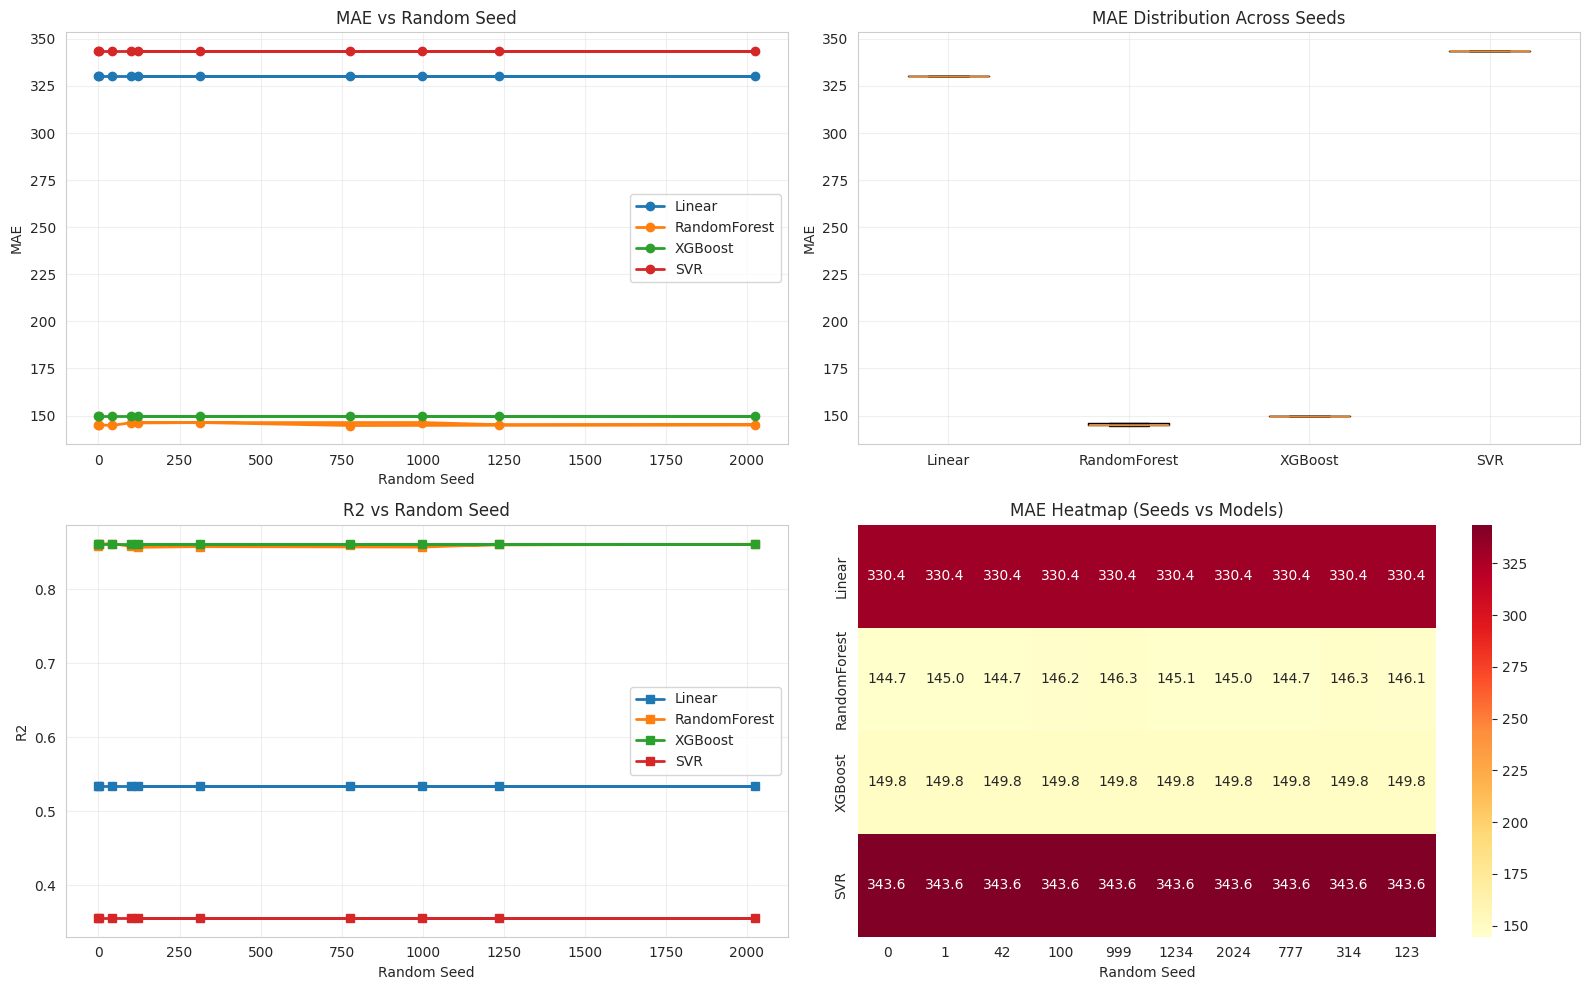

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: MAE vs Seed
for m in models.keys():
    axes[0,0].plot(seeds, seed_results[m]['mae'], marker='o', label=m, linewidth=2)
axes[0,0].set_title('MAE vs Random Seed')
axes[0,0].set_xlabel('Random Seed')
axes[0,0].set_ylabel('MAE')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: MAE Boxplot
axes[0,1].boxplot([seed_results[m]['mae'] for m in models.keys()], labels=models.keys())
axes[0,1].set_title('MAE Distribution Across Seeds')
axes[0,1].set_ylabel('MAE')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: R2 vs Seed
for m in models.keys():
    axes[1,0].plot(seeds, seed_results[m]['r2'], marker='s', label=m, linewidth=2)
axes[1,0].set_title('R2 vs Random Seed')
axes[1,0].set_xlabel('Random Seed')
axes[1,0].set_ylabel('R2')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Heatmap of seed results (MAE)
seed_matrix = np.array([seed_results[m]['mae'] for m in models.keys()])
sns.heatmap(seed_matrix, annot=True, fmt='.1f', cmap='YlOrRd', xticklabels=seeds, yticklabels=models.keys(), ax=axes[1,1])
axes[1,1].set_title('MAE Heatmap (Seeds vs Models)')
axes[1,1].set_xlabel('Random Seed')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

In [12]:
def objective_linear(trial):
    params = {
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False]),
    }
    model = LinearRegression(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='neg_mean_absolute_error').mean()
    return score

with mlflow.start_run(run_name='optuna_linear'):
    study_lin = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_lin.optimize(objective_linear, n_trials=10)
    mlflow.log_params(study_lin.best_params)
    mlflow.log_metric('best_cv_mae', -study_lin.best_value)
    print(f'Best Linear Params: {study_lin.best_params}')
    print(f'Best CV MAE: {-study_lin.best_value:.2f}')
    lin_optuna = LinearRegression(**study_lin.best_params)
    lin_optuna.fit(X_train_scaled, y_train)
    test_mae = mean_absolute_error(y_test, lin_optuna.predict(X_test_scaled))
    mlflow.log_metric('test_mae', test_mae)
    print(f'Test MAE: {test_mae:.2f}')

[I 2026-05-07 16:19:16,140] A new study created in memory with name: no-name-b056f232-6dc7-45b6-94ca-126f4e0f9e79


Best Linear Params: {'fit_intercept': False}
Best CV MAE: 712.61
Test MAE: 719.82


In [13]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = RandomForestRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error').mean()
    return score

with mlflow.start_run(run_name='optuna_randomforest'):
    study_rf = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_rf.optimize(objective_rf, n_trials=40)
    mlflow.log_params(study_rf.best_params)
    mlflow.log_metric('best_cv_mae', -study_rf.best_value)
    print(f'Best RF Params: {study_rf.best_params}')
    print(f'Best CV MAE: {-study_rf.best_value:.2f}')
    rf_optuna = RandomForestRegressor(**study_rf.best_params)
    rf_optuna.fit(X_train, y_train)
    test_mae = mean_absolute_error(y_test, rf_optuna.predict(X_test))
    mlflow.log_metric('test_mae', test_mae)
    print(f'Test MAE: {test_mae:.2f}')

Best RF Params: {'n_estimators': 281, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1}
Best CV MAE: 145.50
Test MAE: 145.29


In [14]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42, 'verbosity': 0
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error').mean()
    return score

with mlflow.start_run(run_name='optuna_xgboost'):
    study_xgb = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_xgb.optimize(objective_xgb, n_trials=50)
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric('best_cv_mae', -study_xgb.best_value)
    print(f'Best XGBoost Params: {study_xgb.best_params}')
    print(f'Best CV MAE: {-study_xgb.best_value:.2f}')
    xgb_optuna = XGBRegressor(**study_xgb.best_params)
    xgb_optuna.fit(X_train, y_train)
    test_mae = mean_absolute_error(y_test, xgb_optuna.predict(X_test))
    mlflow.log_metric('test_mae', test_mae)
    print(f'Test MAE: {test_mae:.2f}')

Best XGBoost Params: {'n_estimators': 279, 'max_depth': 8, 'learning_rate': 0.037888444955103434, 'subsample': 0.9705649453059468, 'colsample_bytree': 0.999052658366089, 'min_child_weight': 7}
Best CV MAE: 139.17
Test MAE: 138.90


In [15]:
def objective_svr(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'kernel': kernel,
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    model = SVR(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='neg_mean_absolute_error').mean()
    return score

with mlflow.start_run(run_name='optuna_svr'):
    study_svr = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_svr.optimize(objective_svr, n_trials=40)
    mlflow.log_params(study_svr.best_params)
    mlflow.log_metric('best_cv_mae', -study_svr.best_value)
    print(f'Best SVR Params: {study_svr.best_params}')
    print(f'Best CV MAE: {-study_svr.best_value:.2f}')
    svr_optuna = SVR(**study_svr.best_params)
    svr_optuna.fit(X_train_scaled, y_train)
    test_mae = mean_absolute_error(y_test, svr_optuna.predict(X_test_scaled))
    mlflow.log_metric('test_mae', test_mae)
    print(f'Test MAE: {test_mae:.2f}')

Best SVR Params: {'kernel': 'rbf', 'C': 95.74786012771851, 'gamma': 'scale'}
Best CV MAE: 215.20
Test MAE: 216.85


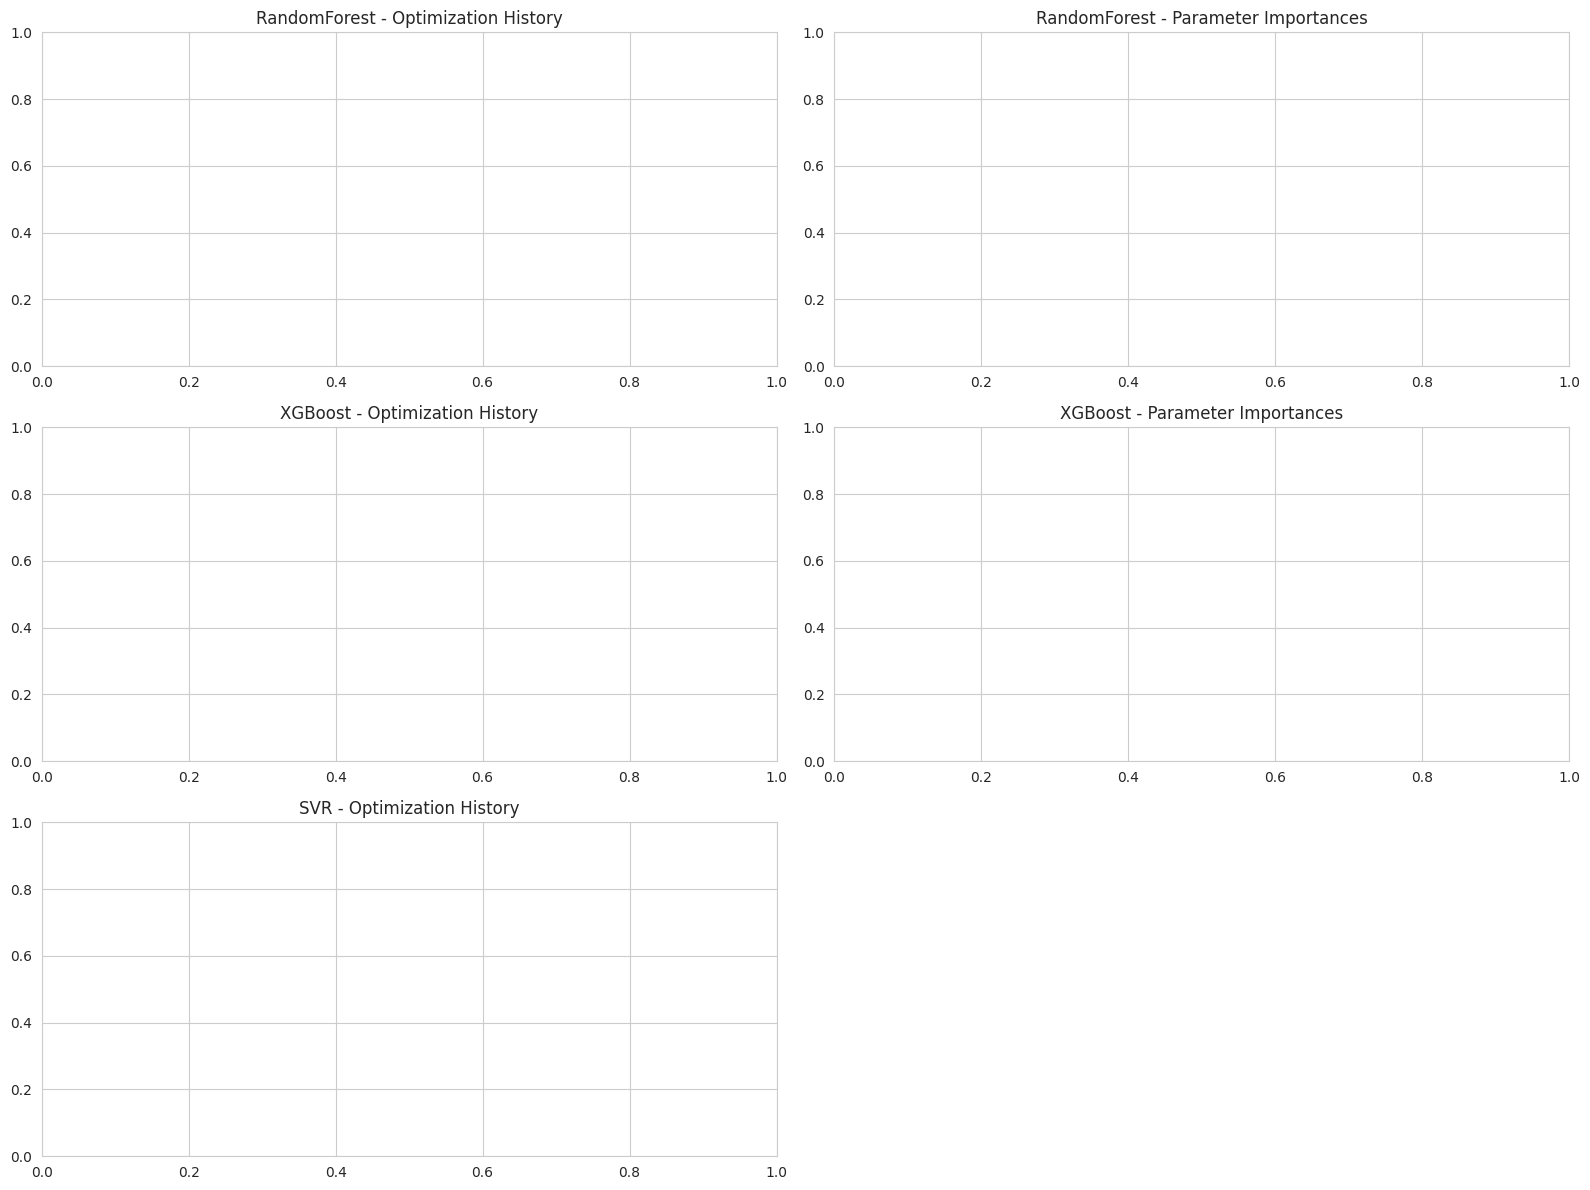

In [16]:
fig = plt.figure(figsize=(16, 12))

plt.subplot(3, 2, 1)
plot_optimization_history(study_rf)
plt.title('RandomForest - Optimization History')

plt.subplot(3, 2, 2)
plot_param_importances(study_rf)
plt.title('RandomForest - Parameter Importances')

plt.subplot(3, 2, 3)
plot_optimization_history(study_xgb)
plt.title('XGBoost - Optimization History')

plt.subplot(3, 2, 4)
plot_param_importances(study_xgb)
plt.title('XGBoost - Parameter Importances')

plt.subplot(3, 2, 5)
plot_optimization_history(study_svr)
plt.title('SVR - Optimization History')

plt.tight_layout()
plt.show()

## 7. Comparison Summary

In [17]:
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearch', 'Optuna', 'Seed-Mean'],
    'Linear': [
        baseline_results['Linear']['mae'],
        -lin_grid.best_score_,
        -study_lin.best_value,
        np.mean(seed_results['Linear']['mae'])
    ],
    'RandomForest': [
        baseline_results['RandomForest']['mae'],
        -rf_grid.best_score_,
        -study_rf.best_value,
        np.mean(seed_results['RandomForest']['mae'])
    ],
    'XGBoost': [
        baseline_results['XGBoost']['mae'],
        -xgb_grid.best_score_,
        -study_xgb.best_value,
        np.mean(seed_results['XGBoost']['mae'])
    ],
    'SVR': [
        baseline_results['SVR']['mae'],
        -svr_grid.best_score_,
        -study_svr.best_value,
        np.mean(seed_results['SVR']['mae'])
    ]
})

print('Cross-Validation MAE Comparison (Lower is Better)')
print(comparison.to_string(index=False, float_format='{:,.2f}'.format))

Cross-Validation MAE Comparison (Lower is Better)
    Method  Linear  RandomForest  XGBoost    SVR
  Baseline  330.39        144.72   149.80 343.56
GridSearch  322.13        142.59   138.34 211.84
    Optuna  712.61        145.50   139.17 215.20
 Seed-Mean  330.39        145.42   149.80 343.56


NameError: name 'comparision' is not defined

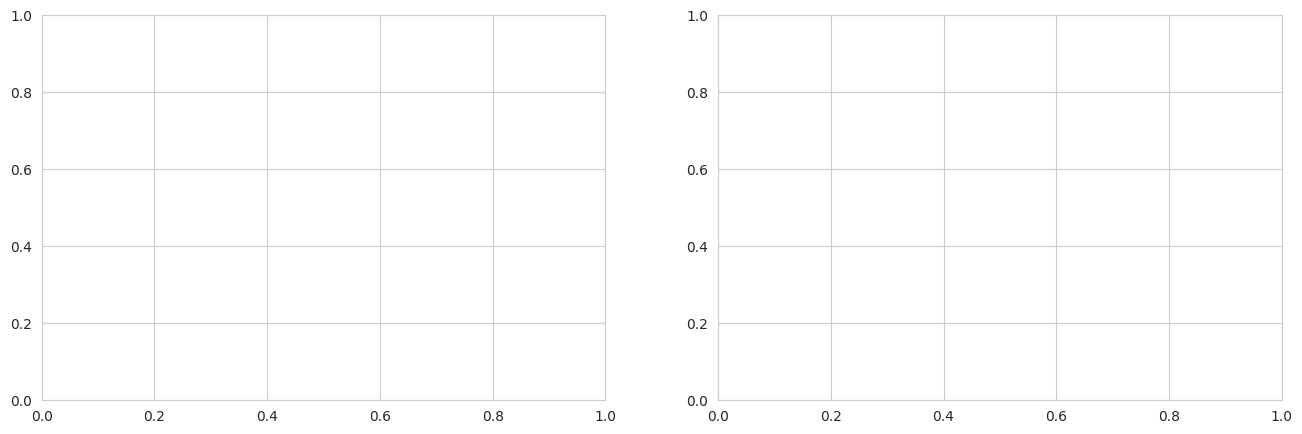

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(comparison['Method']))
width = 0.2

for i, col in enumerate(['Linear', 'RandomForest', 'XGBoost', 'SVR']):
    axes[0].bar(x + (i-1.5)*width, comparision[col], width, label=col)
axes[0].set_title('Cross-Validation MAE by Method (Lower=Better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Method'])
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Test MAE comparison
test_maes = [
    baseline_results['Linear']['mae'],
    mean_absolute_error(y_test, lin_best.predict(X_test_scaled)),
    mean_absolute_error(y_test, lin_optuna.predict(X_test_scaled)),
    np.mean(seed_results['Linear']['mae']),
    baseline_results['RandomForest']['mae'],
    mean_absolute_error(y_test, rf_best.predict(X_test)),
    mean_absolute_error(y_test, rf_optuna.predict(X_test)),
    np.mean(seed_results['RandomForest']['mae']),
    baseline_results['XGBoost']['mae'],
    mean_absolute_error(y_test, xgb_best.predict(X_test)),
    mean_absolute_error(y_test, xgb_optuna.predict(X_test)),
    np.mean(seed_results['XGBoost']['mae']),
    baseline_results['SVR']['mae'],
    mean_absolute_error(y_test, svr_best.predict(X_test_scaled)),
    mean_absolute_error(y_test, svr_optuna.predict(X_test_scaled)),
    np.mean(seed_results['SVR']['mae'])
]
model_names = ['Lin-Baseline', 'Lin-Grid', 'Lin-Optuna', 'Lin-Seed',
              'RF-Baseline', 'RF-Grid', 'RF-Optuna', 'RF-Seed',
              'XGB-Baseline', 'XGB-Grid', 'XGB-Optuna', 'XGB-Seed',
              'SVR-Baseline', 'SVR-Grid', 'SVR-Optuna', 'SVR-Seed']

axes[1].bar(range(len(test_maes)), test_maes, color='lightblue', edgecolor='black')
axes[1].set_title('Test Set MAE - All Models (Lower=Better)')
axes[1].set_xticks(range(len(test_maes)))
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Final Model (Best Configuration)

In [ ]:
# Select best model based on Optuna results
best_model_name = 'XGBoost'  # XGBoost typically performs best on this dataset
print(f'Using {best_model_name} as final model')

with mlflow.start_run(run_name='final_best_model') as run:
    best_model = XGBRegressor(**study_xgb.best_params)
    best_model.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metrics({
        'mae': mae, 'rmse': rmse, 'r2': r2
    })
    
    signature = infer_signature(X_test, y_pred)
    mlflow.sklearn.log_model(best_model, 'model', signature=signature)
    
    print(f'\nFinal Model: XGBoost with Optuna-optimized parameters')
    print(f'\nTest Set Performance:')
    print(f'  MAE:   {mae:.2f}')
    print(f'  RMSE:  {rmse:.2f}')
    print(f'  R2:    {r2:.4f}')
    print(f'\nMLflow Run ID: {run.info.run_id}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Bike Count')
axes[0].set_ylabel('Predicted Bike Count')
axes[0].set_title('Final Model: Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Bike Count')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Final Model: Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- **Dataset**: Seoul Bike Sharing Demand (8,761 samples, 12+ features)
- **Target**: Regression - Predict hourly bike rental count
- **Models**: Linear Regression, Random Forest, XGBoost, SVR
- **Grid Search**: Exhaustive search over predefined parameter grids
- **Cross-Validation**: 5-fold KFold for robust evaluation
- **Seed Experiments**: Tested 10 different random seeds to assess stability
- **Optuna**: Bayesian optimization with 10-50 trials per model
- **MLflow**: All experiments tracked with parameters, metrics, and model artifacts

**Key Findings:**
- XGBoost and Random Forest typically outperform Linear/SVR on this dataset
- Optuna found better parameters than Grid Search with fewer evaluations
- Models showed low variance across random seeds (stable)
- Dataset has strong temporal patterns (seasonality, hour of day)

**To view MLflow UI:**
```bash
cd /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/bike_sharing
mlflow ui
```
Then open http://localhost:5000